In [1]:
import matplotlib.pyplot as plt

import numpy as np

from matplotlib.colors import Normalize
import scienceplots

plt.style.use(['science','notebook','grid'])

pi = np.pi

import scipy as sc

import seaborn
import warnings
warnings.filterwarnings("ignore")

import multiprocessing
import concurrent.futures

from scipy.interpolate import UnivariateSpline, CubicSpline


from tqdm import tqdm

from scipy.optimize import curve_fit
from scipy.interpolate import make_smoothing_spline


In [2]:
%%html
<style>
.jp-Notebook {
  --jp-notebook-max-width: 98%;
}</style>

In [3]:
####################################################################################
'''
General definations and set-up
'''
####################################################################################
pi = np.pi

# tri-length of model
L = 2*pi
dimension = 3

einit = 1*(L**3)

# Size of the system
N = 2**9

nu = 1e-3

Nf = int(N/2 + 1)

mesh = np.linspace(0, L, N, endpoint= False)

dx = mesh[1]-mesh[0]

X ,Y, Z = np.meshgrid(mesh,mesh,mesh,indexing = 'ij')

#Time step defination

dt =  (0.256/N) # Such that increasing resolution will decrease the dt.

T = 40

steps = int(T/dt + 1)

####################################################################################
'''
General definations and set-up for the spectral space
'''
####################################################################################

# The Fourier variables
kx , ky , kz  = np.meshgrid(np.fft.fftfreq(N, dx)*(2*pi),np.fft.fftfreq(N, dx)*(2*pi), np.fft.rfftfreq(N, dx)*(2*pi),indexing= 'ij')

k_vec = np.stack([kx,ky,kz])

k2 = (k_vec[0]**2 + k_vec[1]**2 + k_vec[2]**2)

sqrt_k2 = np.sqrt(k2)

In [4]:
def curl_func(a, k = k_vec ):

    return  np.fft.irfftn(np.stack([
        1j * (k[1] * a[2] - k[2] * a[1]),
        1j * (k[2] * a[0] - k[0] * a[2]),
        1j * (k[0] * a[1] - k[1] * a[0]) ]),axes=(1,2,3))

# Loading Dissipation Field: 2$\nu$$S_{ij}S_{ij}$ 

In [5]:
dissp_field = np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Dissipation_field_and_PDF_statistics/Fractal_Decimated_Dissp_field_D_2p98.npz')['dissp_field']

FileNotFoundError: [Errno 2] No such file or directory: '/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Dissipation_field_and_PDF_statistics/Fractal_Decimated_Dissp_field_D_2p98.npz'

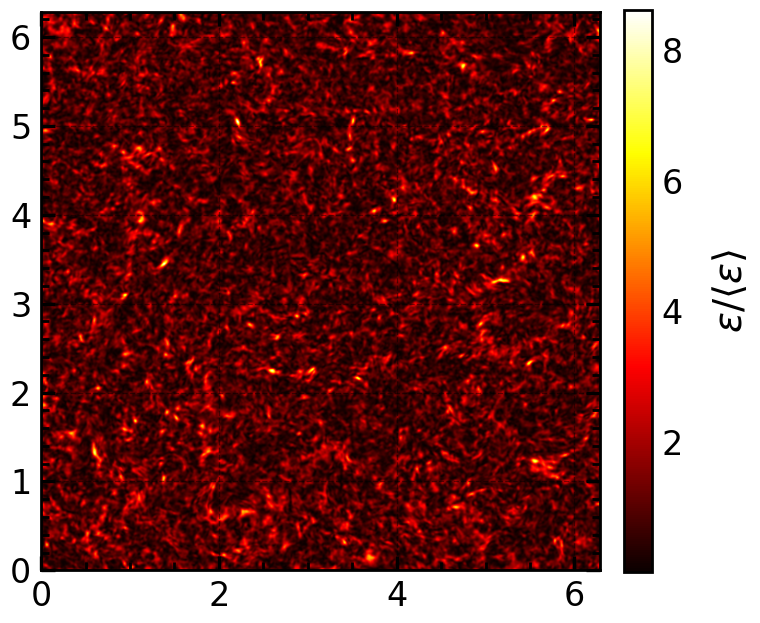

In [6]:
fig, ax = plt.subplots(figsize=(4, 4), dpi=200)

# Normalize to highlight structures while keeping outliers controlled


# Plot
im = ax.imshow(
    (dissp_field[:, 20, :]/np.mean(dissp_field)).T,
    cmap='hot',          # smoother, more contrasty alternative to 'afmhot'
    origin='lower',
    extent=[0, L, 0, L],
    interpolation='spline36' # smooths pixelation
)

# Tick styling
ax.tick_params(axis='both', which='major', labelsize=12, direction='in', length=5, width=1.2)

# Colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label(r'$\epsilon / \langle \epsilon \rangle$', fontsize=14, labelpad=10)
cbar.ax.tick_params(labelsize=12)

# Optional: enhance layout and frame
ax.set_aspect('equal')
plt.tight_layout()
plt.show()


# Calculate the Partition Function

In [8]:
def compute_Zq_r_alpha(dissp_field, r_alpha, q_alpha):
        
    n = dissp_field.shape[0]
    
    Z_q_r_alpha = np.zeros((len(r_alpha), len(q_alpha)))

    for j, r in enumerate(tqdm(r_alpha)):
        
        n_block = n // r  
        
        reshaped = dissp_field.reshape(n_block, r, n_block, r, n_block, r)
                
        block_sum = reshaped.sum(axis=(1, 3, 5))
        
        block_sum_flat = block_sum.ravel()[:, None]          

        Z_q_r_alpha[j, :] = np.log(np.sum(block_sum_flat ** q_alpha[None, :], axis=0)) / (q_alpha - 1)

    return Z_q_r_alpha

In [9]:
r_alpha = 2**(np.arange(1,10))

q_alpha = np.linspace(-30,30,121)
q_alpha = q_alpha[np.where(q_alpha != 1)]

dx =  L/N

In [10]:
Z_q_r_alpha = compute_Zq_r_alpha(dissp_field , r_alpha , q_alpha)

100%|█████████████████████████████████████████████| 9/9 [00:24<00:00,  2.69s/it]


In [11]:
np.savez('Dissipation_field_and_PDF_statistics/Decimated_Singularity_spec_partition_function_D_2p90', Z = Z_q_r_alpha)

In [9]:
Z_q_r_alpha_0p00 = np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Dissipation_field_and_PDF_statistics/Decimated_Singularity_spec_partition_function_P0p0.npz')['Z']
Z_q_r_alpha_0p05 = np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Dissipation_field_and_PDF_statistics/Decimated_Singularity_spec_partition_function_P0p05.npz')['Z']
Z_q_r_alpha_0p1 = np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Dissipation_field_and_PDF_statistics/Decimated_Singularity_spec_partition_function_P0p1.npz')['Z']
Z_q_r_alpha_0p3 = np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Dissipation_field_and_PDF_statistics/Decimated_Singularity_spec_partition_function_P0p3.npz')['Z']
Z_q_r_alpha_0p5 = np.load('/Users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Dissipation_field_and_PDF_statistics/Decimated_Singularity_spec_partition_function_P0p5.npz')['Z']

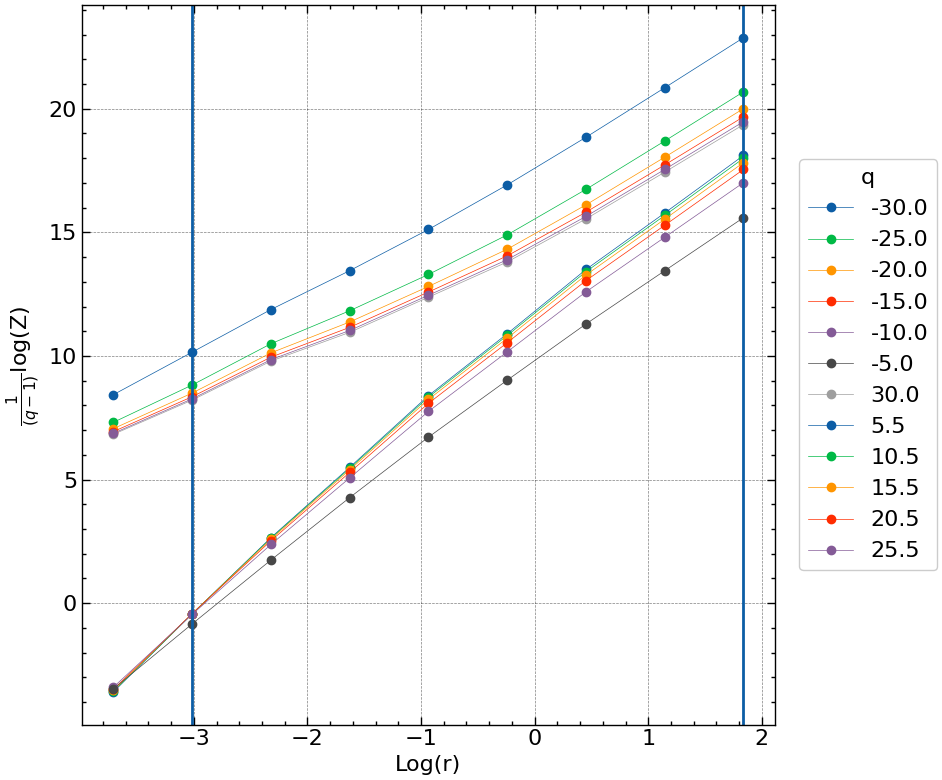

In [10]:
plt.figure(figsize = (8,8))
plt.xlabel("Log(r)")
plt.ylabel(r'$\frac{1}{(q-1)}$log(Z) ')


for i in range(0,len(q_alpha),10):
    if q_alpha[i] != 0 :
        plt.plot(np.log(dx*r_alpha),(Z_q_r_alpha_0p00[:,i]),'o-', ms = 6, label = np.round(q_alpha[i],4), lw = 0.5)
    else:
        plt.plot(np.log(dx*r_alpha),(Z_q_r_alpha_0p00[:,-1]),'o-', ms = 6, label = np.round(q_alpha[-1],4), lw = 0.5)


plt.axvline(np.log(dx*r_alpha[1]))
plt.axvline(np.log(dx*r_alpha[8]))

plt.tight_layout()
plt.legend(bbox_to_anchor = (1.25, 0.5), loc='center right', title = 'q')

plt.show()

# Calculating $D_q$ Vs. q 

In [11]:
D_q_alpha_0p0 = np.zeros(len(q_alpha))
D_q_alpha_0p05 = np.zeros(len(q_alpha))
D_q_alpha_0p1 = np.zeros(len(q_alpha))
D_q_alpha_0p3 = np.zeros(len(q_alpha))
D_q_alpha_0p5 = np.zeros(len(q_alpha))

In [12]:

for indxq, q in enumerate(q_alpha):
    z = np.polyfit(np.log(r_alpha[1:]), Z_q_r_alpha_0p00[1:,indxq],1)
    D_q_alpha_0p0[indxq] = z[0]

for indxq, q in enumerate(q_alpha):
    z = np.polyfit(np.log(r_alpha[1:]), Z_q_r_alpha_0p05[1:,indxq],1)
    D_q_alpha_0p05[indxq] = z[0]

for indxq, q in enumerate(q_alpha):
    z = np.polyfit(np.log(r_alpha[1:]), Z_q_r_alpha_0p1[1:,indxq],1)
    D_q_alpha_0p1[indxq] = z[0]


for indxq, q in enumerate(q_alpha):
    z = np.polyfit(np.log(r_alpha[1:]), Z_q_r_alpha_0p3[1:,indxq],1)
    D_q_alpha_0p3[indxq] = z[0]
    
for indxq, q in enumerate(q_alpha):
    z = np.polyfit(np.log(r_alpha[1:]), Z_q_r_alpha_0p5[1:,indxq],1)
    D_q_alpha_0p5[indxq] = z[0]
    

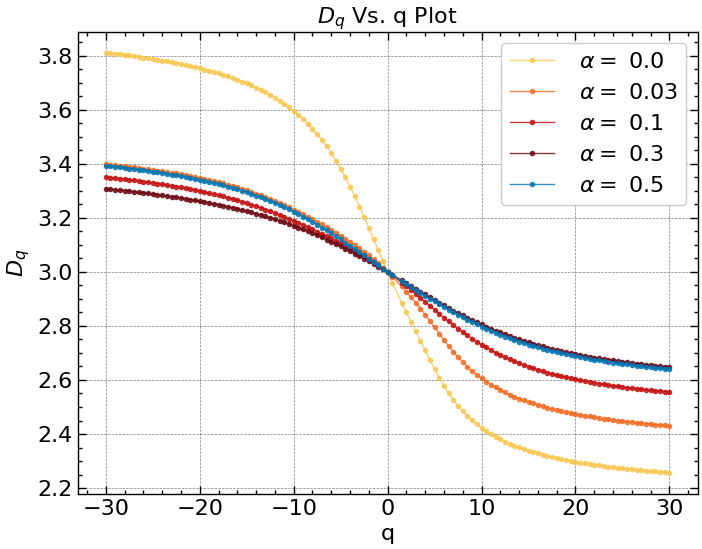

In [13]:
plt.xlabel("q")
plt.ylabel(r'$D_q$')
plt.title(r'$D_q$ Vs. q Plot')
X = [0 , 10 , 20 , 40 , 80]

colors = ['#f9c74f', '#f26b21', '#c30e0e','#6a040f','#0077b6',"#01263d"]
alphas = [0.00, 0.03, 0.10, 0.30, 0.50]

plt.plot(q_alpha,D_q_alpha_0p0,'o-',color = colors[0], label = rf' $\alpha = $ {alphas[0]}' ,ms = 3  ,  lw = 1 , alpha =0.8)
plt.plot(q_alpha,D_q_alpha_0p05,'o-',color = colors[1], label = rf' $\alpha = $ {alphas[1]}' ,ms = 3  ,  lw = 1 , alpha =0.8)
plt.plot(q_alpha,D_q_alpha_0p1,'o-',color = colors[2], label = rf' $\alpha = $ {alphas[2]}' ,ms = 3  ,  lw = 1 , alpha =0.8)
plt.plot(q_alpha,D_q_alpha_0p3,'o-',color = colors[3], label = rf' $\alpha = $ {alphas[3]}' ,ms = 3  ,  lw = 1 , alpha =0.8)
plt.plot(q_alpha,D_q_alpha_0p5,'o-',color = colors[4], label = rf' $\alpha = $ {alphas[4]}' ,ms = 3  ,  lw = 1 , alpha =0.8)

colors = ['#f9c74f', '#f26b21', '#c30e0e','#6a040f','#0077b6',"#01263d"]
alphas = [0.00, 0.03, 0.10, 0.30, 0.50]

# plt.savefig('D_q_vs_q_box_stoc_burg_beta4.jpg')
plt.legend()
plt.show()

# $f(\alpha)$ Vs. $\alpha$

In [14]:
spl_0p0 = make_smoothing_spline(q_alpha,D_q_alpha_0p0)
spl_0p05 = make_smoothing_spline(q_alpha,D_q_alpha_0p05)
spl_0p1 = make_smoothing_spline(q_alpha,D_q_alpha_0p1)
spl_0p3 = make_smoothing_spline(q_alpha,D_q_alpha_0p3)
spl_0p5 = make_smoothing_spline(q_alpha,D_q_alpha_0p5)

In [15]:
q_dumm  =  np.arange(-20,20,0.4)

alpha_dumm_0p0 = np.gradient((spl_0p0(q_dumm)- dimension +1)*(q_dumm-1),q_dumm)
f_alpha_dumm_0p0 = alpha_dumm_0p0*q_dumm - (spl_0p0(q_dumm) - dimension + 1)*(q_dumm-1) + dimension -1 

alpha_dumm_0p05 = np.gradient((spl_0p05(q_dumm)- dimension +1)*(q_dumm-1),q_dumm)
f_alpha_dumm_0p05 = alpha_dumm_0p05*q_dumm - (spl_0p05(q_dumm) - dimension + 1)*(q_dumm-1) + dimension -1 


alpha_dumm_0p1 = np.gradient((spl_0p1(q_dumm)- dimension +1)*(q_dumm-1),q_dumm)
f_alpha_dumm_0p1 = alpha_dumm_0p1*q_dumm - (spl_0p1(q_dumm) - dimension + 1)*(q_dumm-1) + dimension -1 



alpha_dumm_0p3 = np.gradient((spl_0p3(q_dumm)- dimension +1)*(q_dumm-1),q_dumm)
f_alpha_dumm_0p3 = alpha_dumm_0p3*q_dumm - (spl_0p3(q_dumm) - dimension + 1)*(q_dumm-1) + dimension -1 


alpha_dumm_0p5 = np.gradient((spl_0p5(q_dumm)- dimension +1)*(q_dumm-1),q_dumm)
f_alpha_dumm_0p5 = alpha_dumm_0p5*q_dumm - (spl_0p5(q_dumm) - dimension + 1)*(q_dumm-1) + dimension -1 

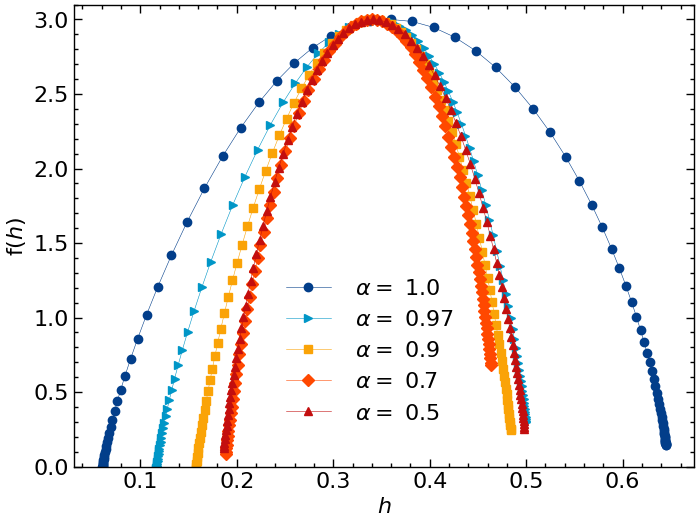

In [39]:
alphas = [1.00, 0.97, 0.90, 0.70, 0.50]

colors = ["#023e8a","#0096c7","#faa307","#ff4800","#c30e0e","#3a5a40"]
markers = ["o", ">", "s", "D", "^","v"]

plt.plot((1/3)*alpha_dumm_0p0,f_alpha_dumm_0p0,'o-',color = colors[0], label = rf' $\alpha = $ {alphas[0]}' ,ms = 6  ,  lw = 0.4 , alpha = 1  , marker = markers[0])
plt.plot((1/3)*alpha_dumm_0p05,f_alpha_dumm_0p05,'o-',color = colors[1], label = rf' $\alpha = $ {alphas[1]}',ms = 6  ,  lw = 0.4 , alpha = 1, marker = markers[1])
plt.plot((1/3)*alpha_dumm_0p1,f_alpha_dumm_0p1,'o-',color = colors[2], label = rf' $\alpha = $ {alphas[2]}' ,ms = 6  ,  lw = 0.4 , alpha = 1, marker = markers[2])
plt.plot((1/3)*alpha_dumm_0p3,f_alpha_dumm_0p3,'o-',color = colors[3], label = rf' $\alpha = $ {alphas[3]}' ,ms = 6  ,  lw = 0.4 , alpha = 1, marker = markers[3])
plt.plot((1/3)*alpha_dumm_0p5,f_alpha_dumm_0p5,'o-',color = colors[4], label = rf' $\alpha = $ {alphas[4]}' ,ms = 6  ,  lw = 0.4 , alpha = 1,  marker = markers[4])

plt.ylim(0,3.1)
plt.ylabel(r'f($h$)')
plt.xlabel(r'$h$')
plt.grid(False)
plt.legend(frameon=False, bbox_to_anchor = (0.31,0.45)) # loc can be adjusted as needed

plt.savefig('singularity_spectra.png', dpi = 300)
plt.show()

In [86]:
# np.savez('Decimated_Singularity_spec_Dq_q_alpha_falpha_P0p5',q = q_alpha,Dq = D_q_alpha ,alpha = alpha_dumm, falpha = f_alpha_dumm )

# Misc. Cross-Checks

In [5]:
a = np.reshape(np.arange(1,17),(4,4))
print(a)

[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]
 [13 14 15 16]]


In [17]:
a_reshaped = np.reshape(a , (2,2,2,2))
print(a_reshaped)

[[[[ 1  2]
   [ 3  4]]

  [[ 5  6]
   [ 7  8]]]


 [[[ 9 10]
   [11 12]]

  [[13 14]
   [15 16]]]]


In [20]:
print(a_reshaped[0,:,0,:])
print(a_reshaped[0,:,1,:])
print(a_reshaped[1,:,0,:])
print(a_reshaped[1,:,1,:])

[[1 2]
 [5 6]]
[[3 4]
 [7 8]]
[[ 9 10]
 [13 14]]
[[11 12]
 [15 16]]


In [12]:
np.sum(a_reshaped , axis = (1,3))

array([[14, 22],
       [46, 54]])